## EDA - Exploratory Data Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [4]:
conexao = sqlite3.connect("../credito.db")
df = pd.read_sql_query("SELECT * FROM clientes", conexao)
conexao.close()

df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


## Distribuição da variável alvo (SeriousDlqin2yrs)
Visualizando em gráfico de barras a proporção de clientes inadimplentes vs não inadimplentes, 
para confirmar visualmente o desbalanceamento identificado na Semana 1 (93,4% vs 6,6%).

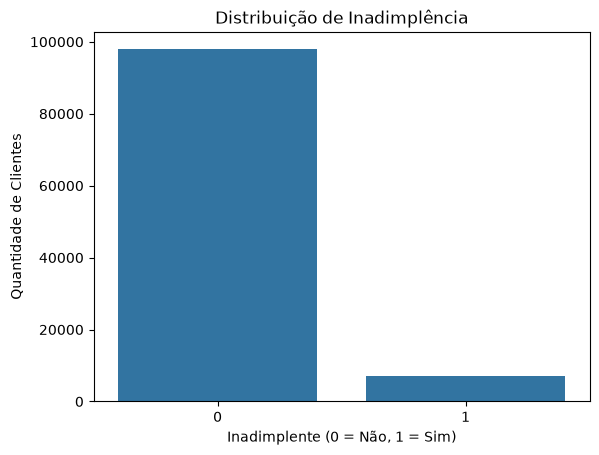

In [ ]:
#função do seaborn que conta quantas linhas existem para cada valor de uma coluna e já desenha isso como gráfico de barras, automaticamente

sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Distribuição de Inadimplência")
plt.xlabel("Inadimplente (0 = Não, 1 = Sim)") 
plt.ylabel("Quantidade de Clientes")
plt.show()

## Distribuição de idade
Visualizando a distribuição de idade dos clientes com um histograma, para confirmar visualmente os outliers identificados na Semana 1 (idade mínima 0 e máxima 109) e observar o formato geral da distribuição.

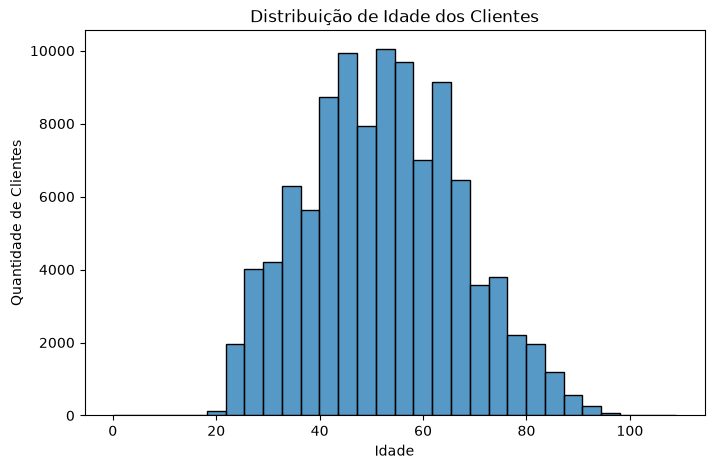

In [ ]:
plt.figure(figsize=(8, 5))                      #cria uma "área de desenho" nova antes do gráfico, definindo o tamanho em polegadas
sns.histplot(data=df, x="age", bins=30)         #bins controla quantas barras aparecem no gráfico
plt.title("Distribuição de Idade dos Clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade de Clientes")
plt.show()

## Outliers em RevolvingUtilizationOfUnsecuredLines e DebtRatio
Visualizando com boxplot os valores extremos identificados na Semana 1, 
que deveriam ser proporções (0 a 1) mas apresentam valores muito acima disso.

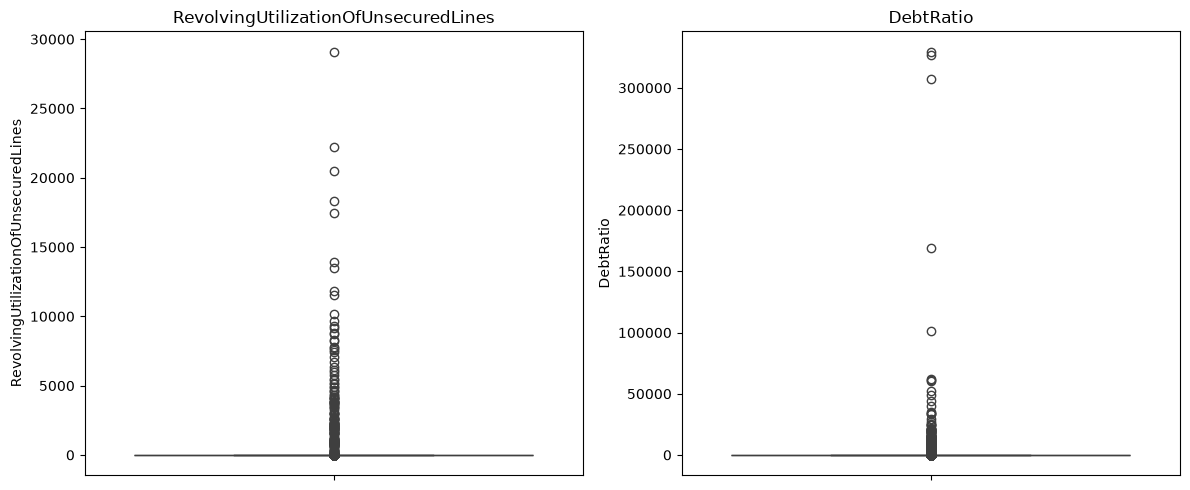

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))  #subplot cria grade de gráficos lado a lado/ 1 linha e 2 colunas

sns.boxplot(data=df, y="RevolvingUtilizationOfUnsecuredLines", ax=eixos[0])  #Esq
eixos[0].set_title("RevolvingUtilizationOfUnsecuredLines")

sns.boxplot(data=df, y="DebtRatio", ax=eixos[1])   #Dir
eixos[1].set_title("DebtRatio")

plt.tight_layout()
plt.show()


# Necessidade de tratar futuramente

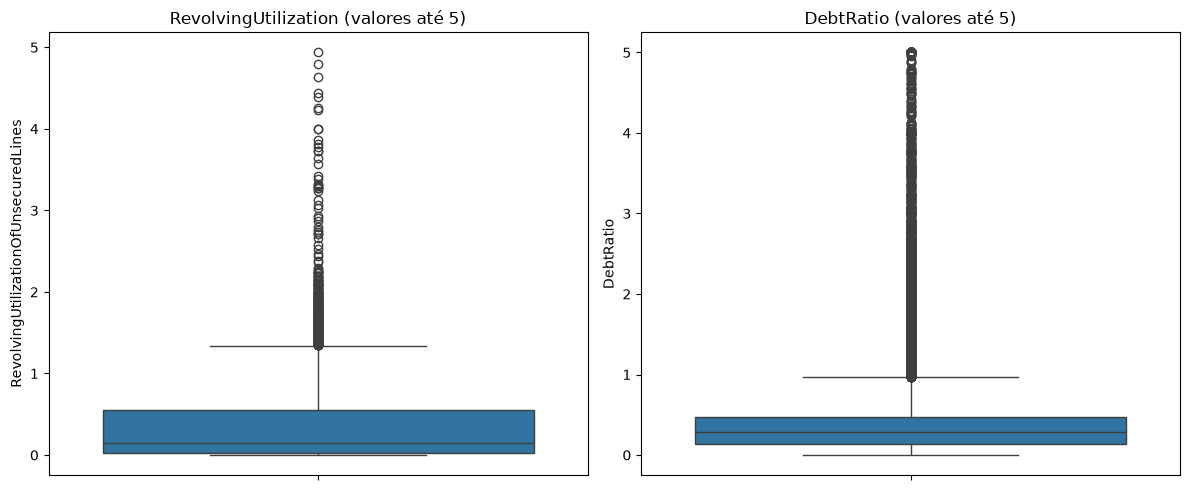

In [ ]:
# Análise individual

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df[df["RevolvingUtilizationOfUnsecuredLines"] <= 5], y="RevolvingUtilizationOfUnsecuredLines", ax=eixos[0])
eixos[0].set_title("RevolvingUtilization (valores até 5)")

sns.boxplot(data=df[df["DebtRatio"] <= 5], y="DebtRatio", ax=eixos[1])
eixos[1].set_title("DebtRatio (valores até 5)")

plt.tight_layout()
plt.show()

# retangulo azul = maioria dos dados

#A linha dentro da caixa: é a mediana (o valor do meio de tudo, mesma ideia que calculamos em SQL pra renda).
#As "linhas" saindo da caixa (os "bigodes"): mostram até onde os dados "normais" se estendem, pra cima e pra baixo, antes de virarem outliers.
#Os pontinhos isolados acima do bigode superior: são os outliers — valores considerados estatisticamente "fora do padrão" comparado com o resto.

A caixa azul é bem baixinha, ficando entre aproximadamente 0 e 0,6 —          |  A caixa azul vai de aproximadamente 0,2 até quase 0,6
confirma que a maioria dos clientes usa uma fração pequena do                 |  a mediana parece estar perto de 0,35-0,4.
limite de crédito disponível,                                                 |
o que faz sentido (a maioria das pessoas não estoura o cartão).               |

## Hipótese: DebtRatio anômalo está relacionado a MonthlyIncome nulo
Comparando a distribuição de DebtRatio entre clientes com renda informada e clientes com renda nula, para investigar se o problema de escala está concentrado num desses grupos.

In [ ]:
df["renda_informada"] = df["MonthlyIncome"].notnull() # cria uma coluna onde lista  verdadeiro ou falso, informando rendas informadas ou não

resumo = df.groupby("renda_informada")["DebtRatio"].describe() 
#agrupa por renda informada e não informada e depois dizemos qual coluna queremos olhar especificamente(indice de endividamento)
print(resumo)

                   count         mean          std  min         25%  \
renda_informada                                                       
False            20781.0  1679.689524  4548.284936  0.0  124.000000   
True             84024.0    27.199594   459.893908  0.0    0.143427   

                        50%          75%       max  
renda_informada                                     
False            1164.00000  2391.000000  329664.0  
True                0.29611     0.482986   61106.5  
